# Chapter 12: Monte Carlo Simulation

This atlas follows the lecture sequence and uses deterministic financial data so
that every code module can run without an internet connection.

## Learning map

1. Random generators, seeds, and resampling
2. Geometric Brownian motion
3. Risk-neutral option pricing
4. Correlated simulations
5. Simulation VaR
6. Sobol sequences and return forecasting

**Code availability:** Yes. Every code cell imports its own dependencies,
contains Chinese exam-oriented comments, and produces an interpretable result.

## How to Study This Chapter

- **First pass:** Read the concept and formula sections without running code.
- **Second pass:** Predict the output and fill in the commented key lines before execution.
- **Third pass:** Run each module independently and explain the result in one sentence.
- **Final review:** Compare related methods and identify when each method should or should not be used.

## Chapter Checklist

- Can I define every variable and state its unit?
- Can I reproduce the main formula or workflow without looking?
- Can I identify the code lines most likely to appear as blanks?
- Can I interpret the output economically or statistically?
- Can I name at least one common implementation error?


## 12.1 Random Seeds, Permutations, and Bootstrap

A fixed seed makes an experiment reproducible. Permutation samples without replacement; bootstrap samples with replacement.


### Structured Review

- **Purpose:** State what the code calculates and why the quantity matters in finance.
- **Inputs:** Identify the required data, parameter units, and expected data type.
- **Process:** Follow the transformation in execution order rather than reading only the final line.
- **Output:** Connect the printed value to an economic or statistical interpretation.

### Exam Focus

- Identify the lines most likely to be removed in a code-completion question.
- Trace dimensions, indices, and units through each intermediate variable.
- Use a small numerical example to check the direction and scale of the answer.

### Common Mistakes

- Reusing a variable with a different meaning.
- Depending on a previous notebook cell for an import or intermediate object.
- Reporting a number without explaining its financial meaning.


In [1]:
import numpy as np

rng = np.random.default_rng(12345)
data = np.array([1, 2, 3, 4, 5])

uniform_draws = rng.uniform(0, 1, 5)
normal_draws = rng.standard_normal(5)
without_replacement = rng.choice(data, size=4, replace=False)
bootstrap = rng.choice(data, size=8, replace=True)

print("Uniform =", np.round(uniform_draws, 4))
print("Normal =", np.round(normal_draws, 4))
print("Without replacement =", without_replacement)
print("Bootstrap =", bootstrap)


Uniform = [0.2273 0.3168 0.7974 0.6763 0.3911]
Normal = [-0.7409 -1.3678  0.6489  0.3611 -1.9529]
Without replacement = [1 2 5 4]
Bootstrap = [1 2 3 1 5 3 4 2]


**Result interpretation.** Re-running the cell produces identical draws because the generator starts from the same seed.

### Result Checklist

- Confirm that the sign and magnitude are economically reasonable.
- Match the output to the formula, decision rule, or statistical hypothesis described above.
- If the result differs from expectation, inspect input frequency, indexing, and parameter order first.


## 12.2 Geometric Brownian Motion Paths

GBM models multiplicative stock-price changes and keeps simulated prices positive.


### Structured Review

- **Purpose:** State what the code calculates and why the quantity matters in finance.
- **Inputs:** Identify the required data, parameter units, and expected data type.
- **Process:** Follow the transformation in execution order rather than reading only the final line.
- **Output:** Connect the printed value to an economic or statistical interpretation.

### Exam Focus

- Identify the lines most likely to be removed in a code-completion question.
- Trace dimensions, indices, and units through each intermediate variable.
- Use a small numerical example to check the direction and scale of the answer.

### Common Mistakes

- Reusing a variable with a different meaning.
- Depending on a previous notebook cell for an import or intermediate object.
- Reporting a number without explaining its financial meaning.


In [2]:
import numpy as np

S0, mu, sigma, T = 50, 0.12, 0.25, 1.0
n_paths, n_steps = 5000, 100
dt = T / n_steps
rng = np.random.default_rng(12345)

shocks = rng.standard_normal((n_paths, n_steps))
# 每一步的对数收益包含漂移修正 -0.5*sigma^2
log_increments = (mu - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * shocks
paths = S0 * np.exp(np.cumsum(log_increments, axis=1))
terminal_prices = paths[:, -1]

print("Mean terminal price =", round(float(terminal_prices.mean()), 4))
print("Median terminal price =", round(float(np.median(terminal_prices)), 4))
print("5% and 95% quantiles =", np.round(np.quantile(terminal_prices, [0.05, 0.95]), 4))


Mean terminal price = 56.615
Median terminal price = 54.8864
5% and 95% quantiles = [36.4392 82.5151]


**Result interpretation.** The mean terminal price is influenced by the real-world expected return mu and is useful for forecasting scenarios.

### Result Checklist

- Confirm that the sign and magnitude are economically reasonable.
- Match the output to the formula, decision rule, or statistical hypothesis described above.
- If the result differs from expectation, inspect input frequency, indexing, and parameter order first.

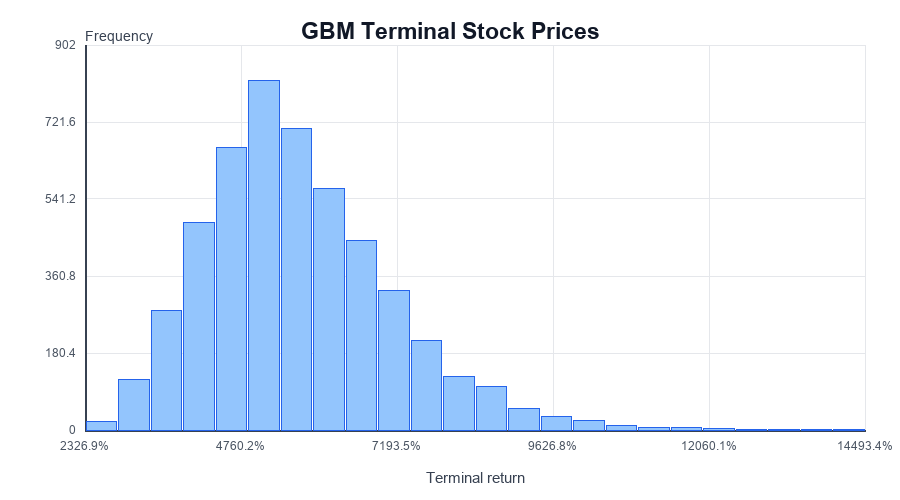


## 12.3 Monte Carlo European Call Pricing

Derivative pricing uses risk-neutral drift r, not the stock's forecast return mu.


### Structured Review

- **Purpose:** State what the code calculates and why the quantity matters in finance.
- **Inputs:** Identify the required data, parameter units, and expected data type.
- **Process:** Follow the transformation in execution order rather than reading only the final line.
- **Output:** Connect the printed value to an economic or statistical interpretation.

### Exam Focus

- Identify the lines most likely to be removed in a code-completion question.
- Trace dimensions, indices, and units through each intermediate variable.
- Use a small numerical example to check the direction and scale of the answer.

### Common Mistakes

- Reusing a variable with a different meaning.
- Depending on a previous notebook cell for an import or intermediate object.
- Reporting a number without explaining its financial meaning.


In [3]:
import numpy as np

S0, K, r, sigma, T = 50, 55, 0.05, 0.25, 1.0
n_simulations = 100_000
rng = np.random.default_rng(12345)

z = rng.standard_normal(n_simulations)
# 风险中性世界中漂移使用无风险利率 r
terminal_prices = S0 * np.exp((r - 0.5 * sigma**2) * T + sigma * np.sqrt(T) * z)
payoffs = np.maximum(terminal_prices - K, 0)
option_price = np.exp(-r * T) * payoffs.mean()
standard_error = np.exp(-r * T) * payoffs.std(ddof=1) / np.sqrt(n_simulations)

print("Call price =", round(float(option_price), 4))
print("Monte Carlo standard error =", round(float(standard_error), 6))


Call price = 4.0311
Monte Carlo standard error = 0.024484


**Result interpretation.** The discounted average payoff estimates the no-arbitrage call value; the standard error measures simulation noise.

### Result Checklist

- Confirm that the sign and magnitude are economically reasonable.
- Match the output to the formula, decision rule, or statistical hypothesis described above.
- If the result differs from expectation, inspect input frequency, indexing, and parameter order first.


## 12.4 Correlated Asset Simulation

Cholesky decomposition transforms independent shocks into shocks with a target correlation matrix.


### Structured Review

- **Purpose:** State what the code calculates and why the quantity matters in finance.
- **Inputs:** Identify the required data, parameter units, and expected data type.
- **Process:** Follow the transformation in execution order rather than reading only the final line.
- **Output:** Connect the printed value to an economic or statistical interpretation.

### Exam Focus

- Identify the lines most likely to be removed in a code-completion question.
- Trace dimensions, indices, and units through each intermediate variable.
- Use a small numerical example to check the direction and scale of the answer.

### Common Mistakes

- Reusing a variable with a different meaning.
- Depending on a previous notebook cell for an import or intermediate object.
- Reporting a number without explaining its financial meaning.


In [4]:
import numpy as np

rng = np.random.default_rng(1204)
target = np.array([
    [1.00, 0.60, 0.25],
    [0.60, 1.00, 0.10],
    [0.25, 0.10, 1.00],
])
independent = rng.standard_normal((20_000, 3))

# L @ L.T 等于目标相关矩阵
cholesky = np.linalg.cholesky(target)
correlated = independent @ cholesky.T
sample = np.corrcoef(correlated, rowvar=False)

print("Target correlation:")
print(target)
print("Simulated correlation:")
print(np.round(sample, 3))


Target correlation:
[[1.   0.6  0.25]
 [0.6  1.   0.1 ]
 [0.25 0.1  1.  ]]
Simulated correlation:
[[1.    0.6   0.246]
 [0.6   1.    0.096]
 [0.246 0.096 1.   ]]


**Result interpretation.** The simulated correlation matrix converges toward the target matrix as the number of draws grows.

### Result Checklist

- Confirm that the sign and magnitude are economically reasonable.
- Match the output to the formula, decision rule, or statistical hypothesis described above.
- If the result differs from expectation, inspect input frequency, indexing, and parameter order first.


## 12.5 Monte Carlo VaR

Simulation VaR estimates the portfolio loss quantile from generated scenarios and can accommodate richer return models.


### Structured Review

- **Purpose:** State what the code calculates and why the quantity matters in finance.
- **Inputs:** Identify the required data, parameter units, and expected data type.
- **Process:** Follow the transformation in execution order rather than reading only the final line.
- **Output:** Connect the printed value to an economic or statistical interpretation.

### Exam Focus

- Identify the lines most likely to be removed in a code-completion question.
- Trace dimensions, indices, and units through each intermediate variable.
- Use a small numerical example to check the direction and scale of the answer.

### Common Mistakes

- Reusing a variable with a different meaning.
- Depending on a previous notebook cell for an import or intermediate object.
- Reporting a number without explaining its financial meaning.


In [5]:
import numpy as np

rng = np.random.default_rng(1205)
position = 1_000_000
confidence = 0.99
n_simulations = 100_000

# 使用厚尾 t 分布展示模拟法不必局限于正态分布
simulated_returns = 0.0003 + 0.012 * rng.standard_t(df=6, size=n_simulations)
losses = -position * simulated_returns
var = np.quantile(losses, confidence)
expected_shortfall = losses[losses >= var].mean()

print("Simulation VaR =", round(float(var), 2))
print("Simulation expected shortfall =", round(float(expected_shortfall), 2))


Simulation VaR = 36955.19
Simulation expected shortfall = 47554.39


**Result interpretation.** The simulated expected shortfall exceeds VaR because it averages the worst one percent of scenarios.

### Result Checklist

- Confirm that the sign and magnitude are economically reasonable.
- Match the output to the formula, decision rule, or statistical hypothesis described above.
- If the result differs from expectation, inspect input frequency, indexing, and parameter order first.


## 12.6 Sobol Sequence and Long-Horizon Returns

Sobol points cover a unit square more evenly than ordinary random draws. Long-horizon forecasts blend arithmetic and geometric means.


### Structured Review

- **Data source:** Record where the observations come from and whether the example is online, local, or simulated.
- **Cleaning:** Inspect missing values, data types, date order, and duplicated observations before calculating returns.
- **Transformation:** Use adjacent prices for one-period returns and compounding for multi-period returns.
- **Storage:** Choose CSV for portability and pickle only for trusted Python workflows that need preserved data types.

### Formula and Workflow

1. Sort observations by date.
2. Clean the price series without inventing unsupported returns.
3. Calculate simple or log returns.
4. Aggregate with products of growth factors or sums of log returns.
5. Validate one observation manually.

### Exam Focus

- Complete `P_t / P_(t-1) - 1`, `log(P_t/P_(t-1))`, and `prod(1+R)-1`.
- Distinguish price filling from return filling.
- Explain why averaging daily returns is not the exact monthly return.

### Common Mistakes

- Calculating returns on unsorted dates.
- Keeping the first missing return in a statistical test.
- Treating a percentage value as if it were already a decimal.


In [6]:
import numpy as np
from scipy import stats

sobol = stats.qmc.Sobol(d=2, scramble=True, seed=1206)
# random_base2 保持 Sobol 序列的平衡性质
points = sobol.random_base2(m=8)
center_distance = np.linalg.norm(points.mean(axis=0) - 0.5)

annual_returns = np.array([0.12, -0.08, 0.20, 0.05, 0.10, -0.03])
arithmetic_mean = annual_returns.mean()
geometric_mean = stats.gmean(1 + annual_returns) - 1
n_history, n_forecast = len(annual_returns), 3
weight = min(n_forecast / n_history, 1)
blended_forecast = weight * geometric_mean + (1 - weight) * arithmetic_mean

print("Sobol sample mean =", np.round(points.mean(axis=0), 4))
print("Distance from square center =", round(float(center_distance), 4))
print("Arithmetic mean =", round(float(arithmetic_mean), 4))
print("Geometric mean =", round(float(geometric_mean), 4))
print("Blended forecast =", round(float(blended_forecast), 4))


Sobol sample mean = [0.5    0.5001]
Distance from square center = 0.0001
Arithmetic mean = 0.06
Geometric mean = 0.0558
Blended forecast = 0.0579


**Result interpretation.** Sobol coverage supports numerical integration, while the blended return forecast reduces horizon-dependent bias.

### Result Checklist

- Confirm that the sign and magnitude are economically reasonable.
- Match the output to the formula, decision rule, or statistical hypothesis described above.
- If the result differs from expectation, inspect input frequency, indexing, and parameter order first.
